In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import datetime
import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-ticks')

In [2]:
import numpy as np
import datetime
import torch
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

class StepByStep(object):
    def __init__(self, model, loss_fn, optimizer):
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model.to(self.device)

        self.train_loader = None
        self.val_loader = None
        self.writer = None
        
        self.losses = []
        self.val_losses = []
        self.total_epochs = 0

        self.train_step_fn = self._make_train_step_fn()
        self.val_step_fn = self._make_val_step_fn()

    def to(self, device):
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"Couldn't send it to {device}, sending it to {self.device} instead.")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader

    def set_tensorboard(self, name, folder='runs'):
        suffix = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
        self.writer = SummaryWriter(f'{folder}/{name}_{suffix}')

    def _make_train_step_fn(self):
        def perform_train_step_fn(x, y):
            self.model.train()
            yhat = self.model(x)
            loss = self.loss_fn(yhat, y)
            
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

            return loss.item()

        return perform_train_step_fn
    
    def _make_val_step_fn(self):
        def perform_val_step_fn(x, y):
            self.model.eval()

            yhat = self.model(x)

            loss = self.loss_fn(yhat, y)

            return loss.item()

        return perform_val_step_fn
            
    def _mini_batch(self, validation=False):
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn

        if data_loader is None:
            return None

        mini_batch_losses = []
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss = step_fn(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)

        loss = np.mean(mini_batch_losses)
        return loss

    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False    
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    def train(self, n_epochs, seed=42):
        self.set_seed(seed)

        for epoch in range(n_epochs):
            self.total_epochs += 1

            loss = self._mini_batch(validation=False)
            self.losses.append(loss)

            with torch.no_grad():
                val_loss = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)

            if self.writer:
                scalars = {'training': loss}
                if val_loss is not None:
                    scalars.update({'validation': val_loss})
                self.writer.add_scalars(main_tag='loss',
                                        tag_scalar_dict=scalars,
                                        global_step=epoch)

        if self.writer:
            self.writer.close()

    def save_checkpoint(self, filename):
        checkpoint = {'epoch': self.total_epochs,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict(),
                      'loss': self.losses,
                      'val_loss': self.val_losses}

        torch.save(checkpoint, filename)

    def load_checkpoint(self, filename):
        checkpoint = torch.load(filename)

        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']

        self.model.train() 

    def predict(self, x):
        self.model.eval() 
        x_tensor = torch.as_tensor(x).float()
        y_hat_tensor = self.model(x_tensor.to(self.device))
        self.model.train()
        return y_hat_tensor.detach().cpu().numpy()

    def plot_losses(self):
        fig = plt.figure(dpi=500,figsize=(10, 4))
        plt.plot(self.losses, label='Training Loss', c='b')
        plt.plot(self.val_losses, label='Validation Loss', c='r')
        plt.yscale('log')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        return fig

    def add_graph(self):
        if self.train_loader and self.writer:
            x_sample, y_sample = next(iter(self.train_loader))
            self.writer.add_graph(self.model, x_sample.to(self.device)),

In [9]:
class CNNstorm1(nn.Module):
    def __init__(self):
        super(CNNstorm1,self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3,6,5,1,2),nn.BatchNorm2d(6),nn.ReLU(),nn.MaxPool2d(2,2))   #output shape:(16,80,80) 40
        self.conv2 = nn.Sequential(nn.Conv2d(6,12,5,1,2),nn.BatchNorm2d(12),nn.ReLU(),nn.MaxPool2d(2,2))    #output shape:(32,40,40) 10
        self.conv3 = nn.Sequential(nn.Conv2d(12,6,5,1,2),nn.BatchNorm2d(6),nn.ReLU(),nn.MaxPool2d(2,2))    #output shape:(32,20,20) 10
        self.out1 = nn.Linear(6*20*20,100)
        self.out2 = nn.Linear(100,10)
        self.out3 = nn.Linear(10,1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Tanh()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self,x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)
        out = out.view(out.size(0),-1)
        out = self.out1(out)
        out = self.relu(out)
        #out = self.dropout(out)
        out = self.out2(out)
        out = self.relu(out)
        #out = self.dropout(out)
        out = self.out3(out)
        #out = self.sigmoid(out)
        
        return out

In [10]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    pass
print('Device:',device)
xiamen = np.load(r'/home/dangw/dangw/nn/project2_xm/1958_2010x_uvm_xiamen_standardscaler.npy')
ss1 = StandardScaler()
xiamen_surge = ss1.fit_transform(np.load('1958_2010y_uvm_xiamen_orgin.npy').reshape(-1,1))
x = xiamen.astype('float32')
y = xiamen_surge.astype('float32')
print(xiamen.shape)
xiamen_surge.shape

Device: cuda
(19182, 3, 160, 160)


(19182, 1)

In [11]:
torch.manual_seed(13)

train_test_n = int(xiamen_surge.shape[0]*0.2)   

x_tensor = torch.as_tensor(x).float()
y_tensor = torch.as_tensor(y).float()


dataset = TensorDataset(x_tensor[train_test_n:], y_tensor[train_test_n:])

test_dataset = TensorDataset(x_tensor[:train_test_n],y_tensor[:train_test_n])

ratio = .875   
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val = n_total - n_train

train_data, val_data = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True
)
val_loader = DataLoader(dataset=val_data, batch_size=1)
test_loader = DataLoader(dataset=test_dataset,batch_size=1)

lr = 0.0001

torch.manual_seed(42)

model = CNNstorm1()
import torch, gc

gc.collect()
torch.cuda.empty_cache()

optimizer = optim.SGD(model.parameters(), lr=lr)

loss_fn = nn.MSELoss(reduction='mean')

n_epochs = 200

sbs = StepByStep(model, loss_fn, optimizer)
sbs.set_loaders(train_loader, val_loader)
sbs.set_tensorboard('classy')
sbs.train(n_epochs=n_epochs)

OrderedDict([('conv1.0.weight', tensor([[[[ 8.6042e-02,  1.0024e-01, -1.7765e-02,  1.1926e-01, -1.6975e-02],
          [ 2.1177e-02, -5.2848e-02,  7.1262e-02,  1.0990e-01, -8.1469e-02],
          [ 8.0544e-02,  6.6627e-03,  7.3833e-02,  7.2322e-03,  4.6313e-02],
          [-4.3606e-02,  6.6726e-02, -1.3684e-03, -6.6478e-02,  1.2406e-02],
          [-7.2749e-02, -2.7163e-02, -5.5755e-02,  7.2019e-02, -1.0014e-01]],

         [[-4.7505e-02, -3.2242e-02, -7.0418e-02,  8.7331e-03, -1.1298e-01],
          [ 9.3187e-02, -1.1435e-01,  6.9878e-02, -1.3715e-03, -5.0598e-02],
          [ 6.5181e-02,  1.1148e-02,  8.1145e-02, -4.0798e-03, -4.6729e-02],
          [ 3.2281e-02, -3.1587e-02,  4.4793e-02,  1.0082e-01,  7.3645e-02],
          [-5.2656e-02,  5.9132e-02,  1.1193e-02,  4.8182e-02, -6.8938e-02]],

         [[-1.1755e-01, -3.1114e-02, -7.7180e-02,  1.1491e-01,  5.3375e-02],
          [ 4.1121e-02,  4.3680e-02, -4.2350e-03,  8.2256e-02, -8.6975e-02],
          [ 8.4735e-03, -6.7708e-02,  3.

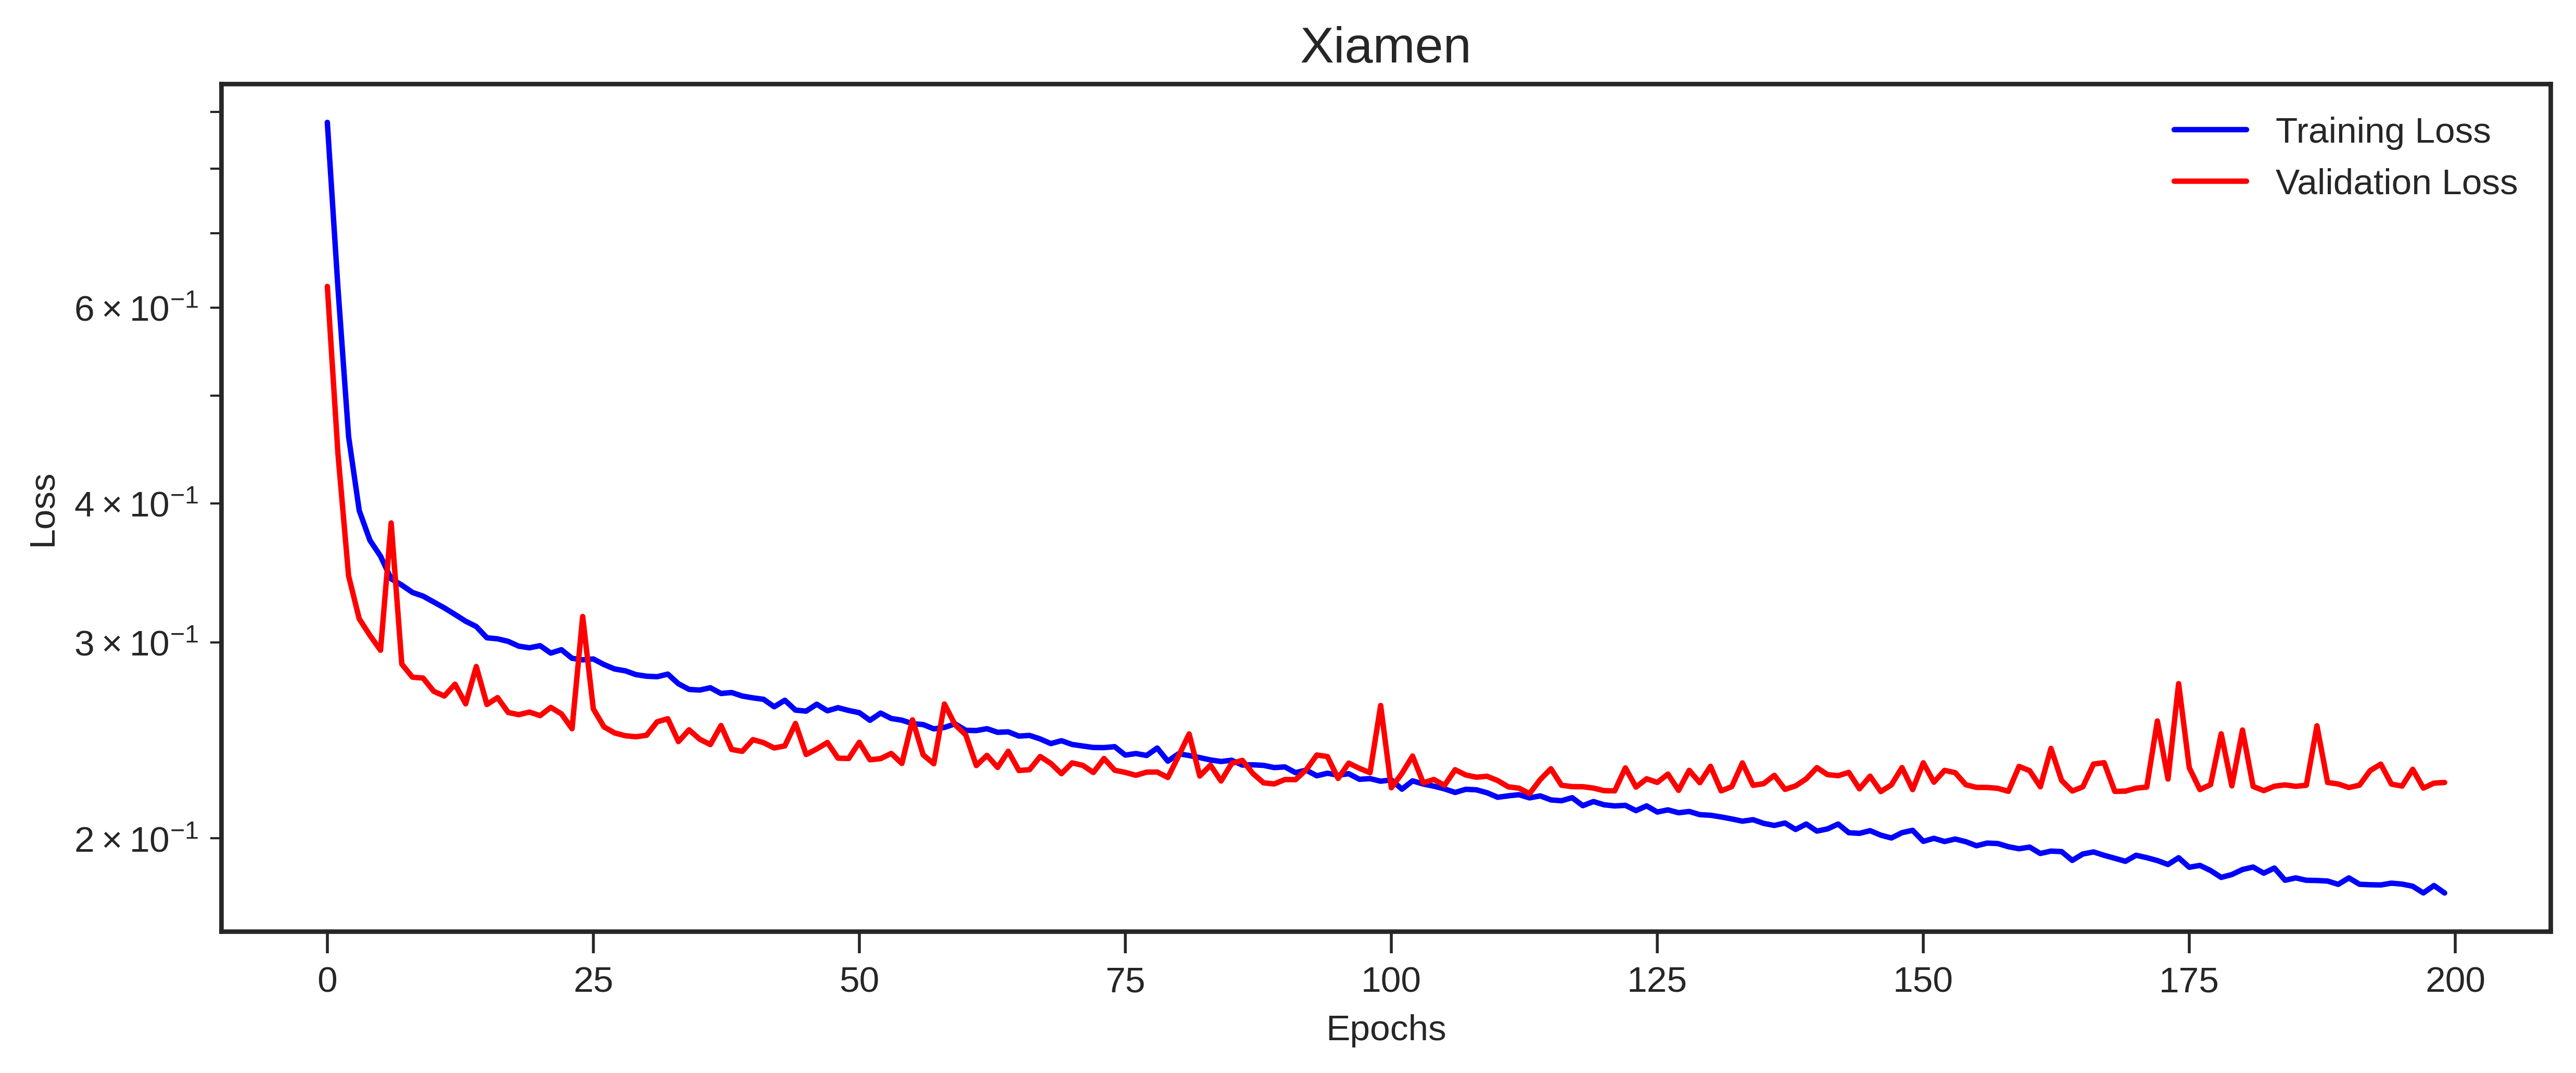

In [12]:
import os
import datetime
fig = sbs.plot_losses()
suffix_time = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
name_graph = suffix_time + '.png'
output_path = os.path.join(os.path.abspath('.'),'pictures',name_graph)
plt.title('Xiamen',fontsize=14)
plt.savefig(output_path,dpi=500)
plt.show()

In [13]:
# Evalute and Testing
import torch
from torch.utils.data import DataLoader
import os

model = model.to('cpu')
model.eval()

def evalute(dataset):
    predict = []
    actual = []
    for x,inputs in dataset:
        logits  = model(x)
        #print(logits.detach().numpy().flatten()[0],inputs.numpy())
        actual.append(list(inputs.numpy()))
        predict.append(list(logits.detach().numpy().flatten()))
    res_actual = np.array(actual).reshape(-1,1)
    res_predict = np.array(predict).reshape(-1,1)
    return res_actual,res_predict

In [19]:
model_path = 'model.pth'
torch.save(model,model_path)

the_model = torch.load('model.pth')
# the_model.state_dict()